In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from glob import glob

from keras.models import *
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.activations import *

In [ ]:
train_cov_dir = '/content/gdrive/MyDrive/Covid_dataset/train/New Covid ds/'
train_nor_dir = '/content/gdrive/MyDrive/Covid_dataset/train/NORMAL/'

test_cov_dir = '/content/gdrive/MyDrive/COVID19_test/'
test_nor_dir = '/content/gdrive/MyDrive/NORMALtest/'

train_cov_dir_glob = '/content/gdrive/MyDrive/Covid_dataset/train/New Covid ds/*'
train_nor_dir_glob = '/content/gdrive/MyDrive/Covid_dataset/train/NORMAL/*'

train_cov_img = glob(train_cov_dir_glob)
train_nor_img = glob(train_nor_dir_glob)

In [ ]:
train__dir = '/content/gdrive/MyDrive/NORMALtest/'

train_pnu_dir_glob = '/content/gdrive/MyDrive/Pneumonia extra/Pneumonia_576/*'
train_pnu_img = glob(train_pnu_dir_glob)

In [ ]:
img_shape = (256,256)
def transform_img(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  reshape_img = cv2.resize(img_gray,img_shape)
  return reshape_img/255.0

In [ ]:
model_prev = load_model('/content/gdrive/MyDrive/Lung Segmentation/Better_Segment_Model.h5')

In [ ]:
def extest(temp_img,kernel=np.ones((5,5),np.uint8)):

  int_img = cv2.imread(temp_img)
  img = transform_img(int_img)

  mask = model_prev.predict(np.array([img]))

  img_f = np.squeeze(np.array([img]))

  plt.figure(figsize=(15,9))
  plt.subplot(1,4,1)
  plt.axis("off")
  plt.title('Original Image')
  plt.imshow(img_f,cmap ='gray')

  mask_f = np.squeeze(mask[0])

  plt.subplot(1,4,2)
  plt.axis("off")
  plt.title('Predicted Mask')
  plt.imshow(mask_f,cmap ='gray')

  _mask = (mask_f>0.5).astype(np.uint8)

  plt.subplot(1,4,3)
  plt.axis("off")
  plt.title('Clear Edge Mask')
  plt.imshow(_mask,cmap ='gray')

  aimg = cv2.bitwise_and(img_f,img_f,mask = _mask)
  plt.subplot(1,4,4)
  plt.axis("off")
  plt.title('Segmented lung')
  plt.imshow(aimg,cmap ='gray')

  plt.show()

In [ ]:
extest('/content/gdrive/MyDrive/Lung Segmentation/CXR_png/CHNCXR_0006_0.png')

UnimplementedError: ignored

In [ ]:
def test(temp_img,p_ath,kernel = np.ones((5, 5),np.uint8)):
  size = len(temp_img)
  temp = np.array(temp_img)
  for i in range(size):
    img = cv2.imread(temp[i])
    img = transform_img(img)

    mask = model_prev.predict(np.array([img]))
    img_f = np.squeeze(np.array([img]))

    #for showing the original image
    # img_f = np.squeeze(np.array([img]))
    # plt.imshow(img_f,cmap='gray')
    # plt.show()

    mask_f = np.squeeze(mask[0])

    _mask = (mask_f>0.5).astype(np.uint8)


    aimg = cv2.bitwise_and(img_f,img_f,mask = _mask)
    plt.axis("off")

    name = f'{p_ath}{i}.jpg'
    plt.imshow(aimg,cmap = 'gray')
    plt.savefig(name)

In [ ]:
cov_path = '/content/gdrive/MyDrive/Lung_Mask_clear/train/new 1500 cov/'
test(train_cov_img,cov_path)

In [ ]:
nor_path = '/content/gdrive/MyDrive/Lung_Mask_clear/train/normal/'
test(train_nor_img,nor_path)

In [ ]:
pnu_path = '/content/gdrive/MyDrive/Pneumonia extra/Pneumonia_seg/'
test(train_pnu_img,pnu_path)

In [ ]:
test_cov_dir_glob = '/content/gdrive/MyDrive/COVID19_test/*'
test_nor_dir_glob = '/content/gdrive/MyDrive/NORMALtest/*'

In [ ]:
test_cov_img = glob(test_cov_dir_glob)
test_nor_img = glob(test_nor_dir_glob)

In [ ]:
len(test_cov_img),len(test_nor_img)

(116, 317)

In [ ]:
test_cov_path = '/content/gdrive/MyDrive/Fine dataset/test/covid1/'
test_nor_path = '/content/gdrive/MyDrive/Fine dataset/test/normal1/'

In [ ]:
test(test_cov_img,test_cov_path)

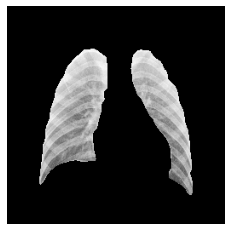

In [ ]:
test(test_nor_img,test_nor_path)

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import math

import keras
from keras import models
from keras import layers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense, Conv2D , SeparableConv2D, MaxPooling2D , Flatten , Dropout , BatchNormalization, Activation
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.callbacks import ReduceLROnPlateau
from keras import backend as K
from keras import optimizers
from sklearn.metrics import classification_report, recall_score, precision_score, confusion_matrix, f1_score, accuracy_score
import tensorflow as tf

In [ ]:
train_data_dir = '/content/gdrive/MyDrive/Fine dataset/train/'
test_data_dir = '/content/gdrive/MyDrive/Fine dataset/test/'

In [ ]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        # zoom_range=0.4,
        validation_split=0.2
        )

train_gen = train_datagen.flow_from_directory(
        directory = train_data_dir,
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        subset='training'
        )
val_gen = train_datagen.flow_from_directory(
        directory = train_data_dir,
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        subset='validation'
        )

Found 1208 images belonging to 2 classes.
Found 300 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(
        rescale=1./255
        )
test_gen = test_datagen.flow_from_directory(
    directory = test_data_dir,
    target_size=(256,256),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True
)

Found 94 images belonging to 2 classes.


In [ ]:
image_size = (256,256,3)

In [ ]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=image_size),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(2,activation='softmax')
])

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics = ['acc'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 246016)            0         
                                                                 
 dense (Dense)               (None, 128)               3

In [ ]:
from keras.callbacks import EarlyStopping
Early_stop = EarlyStopping(monitor = 'val_acc',patience = 10)

In [ ]:
history = model.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=[Early_stop])

Epoch 1/30
38/38 [==============================] - 152s 4s/step - loss: 0.7616 - acc: 0.6738 - val_loss: 0.5126 - val_acc: 0.7667
Epoch 2/30
38/38 [==============================] - 105s 3s/step - loss: 0.4509 - acc: 0.7980 - val_loss: 0.3948 - val_acc: 0.8133
Epoch 3/30
38/38 [==============================] - 103s 3s/step - loss: 0.3379 - acc: 0.8634 - val_loss: 0.3742 - val_acc: 0.8133
Epoch 4/30
38/38 [==============================] - 103s 3s/step - loss: 0.2669 - acc: 0.8974 - val_loss: 0.3024 - val_acc: 0.8900
Epoch 5/30
38/38 [==============================] - 103s 3s/step - loss: 0.2112 - acc: 0.9189 - val_loss: 0.2519 - val_acc: 0.9200
Epoch 6/30
38/38 [==============================] - 103s 3s/step - loss: 0.1763 - acc: 0.9387 - val_loss: 0.2411 - val_acc: 0.9133
Epoch 7/30
38/38 [==============================] - 103s 3s/step - loss: 0.1265 - acc: 0.9619 - val_loss: 0.2462 - val_acc: 0.9167
Epoch 8/30
38/38 [==============================] - 104s 3s/step - loss: 0.0891 - a

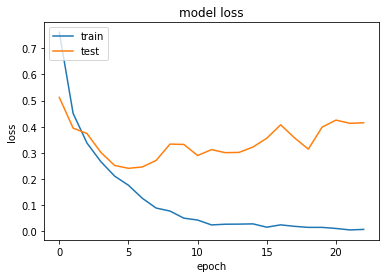

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

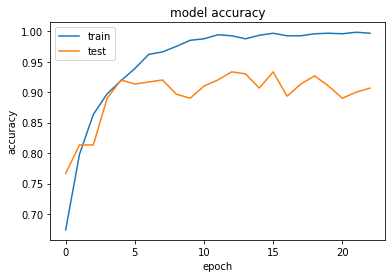

3/3 - 13s - loss: 1.6538 - acc: 0.7872 - 13s/epoch - 4s/step


In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


test_acc = model.evaluate(test_gen, verbose=2)

In [ ]:
model.save('/content/gdrive/MyDrive/Covid_dataset/clear_seg__CNN.h5')

In [ ]:
from keras.models import load_model

In [ ]:
Mod = load_model('/content/gdrive/MyDrive/Covid_dataset/clear_seg__CNN.h5')

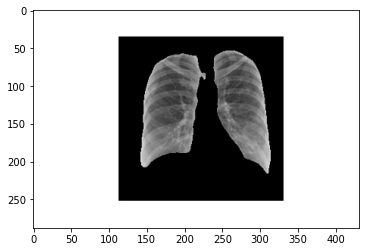

In [ ]:

image_path = plt.imread('/content/gdrive/MyDrive/Fine dataset/test/covid/25.jpg')
path = '/content/gdrive/MyDrive/Fine dataset/test/covid/25.jpg'
plt.imshow(image_path,cmap = 'gray')

In [ ]:
from keras.preprocessing import image
test_image = image.load_img(path, target_size = (256,256,3))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = Mod.predict(test_image)
answer = np.argmax(result,axis=1)
train_gen.class_indices
if result[0][0]==1:
    prediction = 'covid'
else :
    prediction = 'normal'
print(prediction)

covid
